# Pandas Merge (Join)

Panda's way of joining tables together; where DataFrames are merged together.

## Required Imports

In [47]:
from pathlib import Path

import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Sources

### Mounting drive

### Utility functions

In [48]:
def get_df(file_name: str):
  filepath = Path("..")/"data"/file_name
  return pd.read_csv(filepath, index_col=0)

### Sources

In [49]:
actors_movies = get_df('actors_movies.csv')
bank_of_america = get_df('bank_of_america.csv')
cal = get_df('cta_calendar.csv')
casts = get_df('casts.csv')
crews = get_df('crews.csv')
employees = get_df('employees.csv')
financials = get_df('financials.csv')
gdp = get_df('gdp.csv')
jp_morgan = get_df('jp_morgan.csv')
movies = get_df('movies.csv')
movie_to_genres = get_df('movie_to_genres.csv')
land_use = get_df('land_use.csv')
census = get_df('Chicago_census.csv')
licenses = get_df('licenses.csv')
ratings = get_df('ratings.csv')
recession = get_df('recession.csv')
ridership = get_df('cta_ridership.csv')
sequels = get_df('sequels.csv')
taglines = get_df('taglines.csv')
taxi_owners_df = get_df('taxi_owners.csv')
taxi_vehicles = get_df('taxi_vehicles.csv')
top_cust = get_df('top_cust.csv')
wards = get_df('Chicago_wards.csv')
wells_fargo = get_df('wells_fargo.csv')
zip_demo = get_df('zip_demo.csv')

## `pandas.DataFrame.merge()` - Inner Join (default)


### Syntax

```python
pd.DataFrame.merge()
```

### Usage

In [50]:
taxi_own_veh = taxi_owners_df.merge(taxi_vehicles, on='vid')
taxi_own_veh

,rid,vid,owner_x,address,zip,make,model,year,fuel_type,owner_y
0,T6285,6285,AGEAN TAXI LLC,4536 N. ELSTON AVE.,60630,NISSAN,ALTIMA,2011,HYBRID,AGEAN TAXI LLC
1,T4862,4862,MANGIB CORP.,5717 N. WASHTENAW AVE.,60659,HONDA,CRV,2014,GASOLINE,MANGIB CORP.
2,T1495,1495,"FUNRIDE, INC.",3351 W. ADDISON ST.,60618,TOYOTA,SIENNA,2015,GASOLINE,"FUNRIDE, INC."
3,T4231,4231,ALQUSH CORP.,6611 N. CAMPBELL AVE.,60645,TOYOTA,CAMRY,2014,HYBRID,ALQUSH CORP.
4,T5971,5971,EUNIFFORD INC.,3351 W. ADDISON ST.,60618,TOYOTA,SIENNA,2015,GASOLINE,EUNIFFORD INC.
...,...,...,...,...,...,...,...,...,...,...
3514,T4453,4453,IMAGIN CAB CORP,3351 W. ADDISON ST.,60618,FORD,ESCAPE,2010,HYBRID,IMAGIN CAB CORP
3515,T121,121,TRIBECA CAB CORP,4536 N. ELSTON AVE.,60630,FORD,C-MAX,2014,HYBRID,TRIBECA CAB CORP
3516,T3465,3465,AMIR EXPRESS INC,3351 W. ADDISON ST.,60618,TOYOTA,CAMRY,2014,HYBRID,AMIR EXPRESS INC
3517,T1962,1962,KARY CAB COMPANY,4707 N. KENTON AVE.,60630,TOYOTA,CAMRY,2014,HYBRID,KARY CAB COMPANY


## `pandas.DataFrame.merge(on=list[str])` - Inner Join (default)

In [51]:
# Merge the ridership and cal tables
ridership_cal = ridership.merge(cal, on=['year', 'month', 'day'])
ridership_cal

,station_id,year,month,day,rides,day_type
0,40010,2019,1,1,576,Sunday/Holiday
1,40010,2019,1,2,1457,Weekday
2,40010,2019,1,3,1543,Weekday
3,40010,2019,1,4,1621,Weekday
4,40010,2019,1,5,719,Saturday
...,...,...,...,...,...,...
3280,41660,2019,12,27,13898,Weekday
3281,41660,2019,12,28,9485,Saturday
3282,41660,2019,12,29,7581,Sunday/Holiday
3283,41660,2019,12,30,15332,Weekday


## `pandas.DataFrame.merge(how='inner'|'left'|'right'|'outer'|'cross')`



### `pandas.DataFrame.merge(how='left')`

In [52]:
# Filtering data source
toy_story_filter = movies['title'].str.contains('Toy Story')
toy_story = movies[toy_story_filter]
toy_story

,id,title,popularity,release_date
103,10193,Toy Story 3,59.995418,2010-06-16
2637,863,Toy Story 2,73.575118,1999-10-30
3716,862,Toy Story,73.640445,1995-10-30


In [53]:
# Merge toy story movies with associated taglines
toystory_tag = toy_story.merge(taglines, on='id', how='left')
toystory_tag

,id,title,popularity,release_date,tagline
0,10193,Toy Story 3,59.995418,2010-06-16,No toy gets left behind.
1,863,Toy Story 2,73.575118,1999-10-30,The toys are back!
2,862,Toy Story,73.640445,1995-10-30,NaN


### `pandas.DataFrame.merge(how='right')`

#### Right join to find unique movies

In [54]:
action_movies = movie_to_genres[movie_to_genres['genre'] == 'Action']
action_movies

,movie_id,genre
3,11,Action
14,18,Action
25,22,Action
26,24,Action
42,58,Action
...,...,...
12126,381902,Action
12128,385383,Action
12136,389425,Action
12144,407887,Action


In [55]:
scifi_movies = movie_to_genres[movie_to_genres['genre'] == 'Science Fiction']
scifi_movies

,movie_id,genre
2,11,Science Fiction
17,18,Science Fiction
20,19,Science Fiction
38,38,Science Fiction
49,62,Science Fiction
...,...,...
12000,335866,Science Fiction
12020,347548,Science Fiction
12063,360188,Science Fiction
12092,367551,Science Fiction


In [56]:
# Merge action_movies to the scifi_movies with right join
action_scifi = action_movies.merge(scifi_movies, on='movie_id', how='right',
                                   suffixes=('_act','_sci'))

action_scifi

,movie_id,genre_act,genre_sci
0,11,Action,Science Fiction
1,18,Action,Science Fiction
2,19,NaN,Science Fiction
3,38,NaN,Science Fiction
4,62,NaN,Science Fiction
...,...,...,...
530,335866,NaN,Science Fiction
531,347548,NaN,Science Fiction
532,360188,NaN,Science Fiction
533,367551,Action,Science Fiction


In [57]:
# From action_scifi, select only the rows where the genre_act column is null
scifi_only = action_scifi[action_scifi['genre_act'].isnull()]
scifi_only


,movie_id,genre_act,genre_sci
2,19,NaN,Science Fiction
3,38,NaN,Science Fiction
4,62,NaN,Science Fiction
5,68,NaN,Science Fiction
6,74,NaN,Science Fiction
...,...,...,...
529,333371,NaN,Science Fiction
530,335866,NaN,Science Fiction
531,347548,NaN,Science Fiction
532,360188,NaN,Science Fiction


In [58]:
# Merge the movies and scifi_only tables with an inner join
movies_and_scifi_only = movies.merge(scifi_only, left_on="id", right_on="movie_id")
movies_and_scifi_only

,id,title,popularity,release_date,movie_id,genre_act,genre_sci
0,18841,The Lost Skeleton of Cadavra,1.680525,2001-09-12,18841,NaN,Science Fiction
1,26672,The Thief and the Cobbler,2.439184,1993-09-23,26672,NaN,Science Fiction
2,15301,Twilight Zone: The Movie,12.902975,1983-06-24,15301,NaN,Science Fiction
3,8452,The 6th Day,18.447479,2000-11-17,8452,NaN,Science Fiction
4,1649,Bill & Ted's Bogus Journey,11.349664,1991-07-19,1649,NaN,Science Fiction
...,...,...,...,...,...,...,...
253,245703,Midnight Special,32.717853,2016-02-18,245703,NaN,Science Fiction
254,3509,A Scanner Darkly,26.093043,2006-05-25,3509,NaN,Science Fiction
255,42188,Never Let Me Go,30.983397,2010-09-15,42188,NaN,Science Fiction
256,18045,The Dark Hours,1.428483,2005-03-11,18045,NaN,Science Fiction


#### Popular genres with right join

In [59]:
# Top 10 Movies
pop_movies = movies.sort_values('popularity', ascending=False).head(10)
pop_movies

,id,title,popularity,release_date
4546,211672,Minions,875.581305,2015-06-17
4343,157336,Interstellar,724.247784,2014-11-05
1966,293660,Deadpool,514.569956,2016-02-09
2423,118340,Guardians of the Galaxy,481.098624,2014-07-30
4220,76341,Mad Max: Fury Road,434.278564,2015-05-13
1867,135397,Jurassic World,418.708552,2015-06-09
4375,22,Pirates of the Caribbean: The Curse of the Bla...,271.972889,2003-07-09
1106,119450,Dawn of the Planet of the Apes,243.791743,2014-06-26
4216,131631,The Hunger Games: Mockingjay - Part 1,206.227151,2014-11-18
2614,177572,Big Hero 6,203.734590,2014-10-24


<module 'matplotlib.pyplot' from '/Users/anthony/workspace/projects/data-science/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>

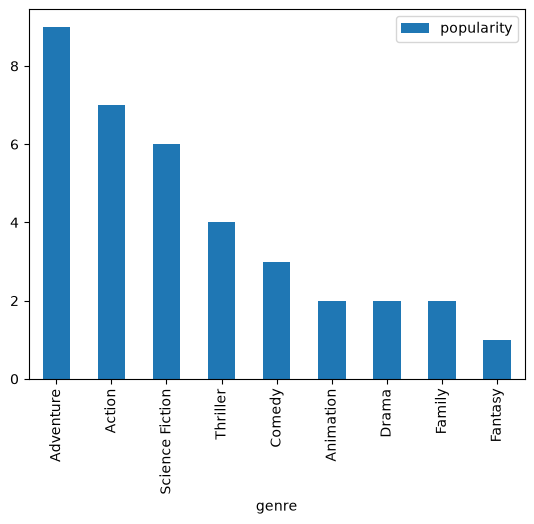

In [60]:

# Use right join to merge the movie_to_genres and pop_movies tables
genres_movies = movie_to_genres.merge(pop_movies, how='right',
                                      left_on="movie_id",
                                      right_on="id")

# Count the number of genres
genre_count = genres_movies.groupby('genre') \
  .agg({'popularity':'count'})


# Plot a bar chart of the genre_count
genre_count.sort_values('popularity', ascending=False).plot(kind='bar')
plt

### `pandas.DataFrame.merge(how='outer')`



In [61]:
iron_man_1_movie_id = movies[movies['title'].str.fullmatch('Iron Man')]['id']
iron_man_2_movie_id = movies[movies['title'].str.fullmatch('Iron Man 2')]['id']

# iron_1_actors = actors_movies
iron_1_actors = casts[casts.index.isin(iron_man_1_movie_id)].loc[:, ['id', 'character', 'name']]
iron_2_actors = casts[casts.index.isin(iron_man_2_movie_id)].loc[:, ['id', 'character', 'name']]

In [62]:
# Merge iron_1_actors to iron_2_actors on id with outer join using suffixes
iron_1_and_2 = iron_1_actors.merge(iron_2_actors,
                                     how="outer",
                                     on="id",
                                     suffixes=('_1','_2'))

# Create an index that returns true if name_1 or name_2 are null
m = ((iron_1_and_2['name_1'].isnull()) |
     (iron_1_and_2['name_2'].isnull()))

# Print the first few rows of iron_1_and_2
iron_1_and_2[m].head()

,id,character_1,name_1,character_2,name_2
0,1229,Obadiah Stane / Iron Monger,Jeff Bridges,NaN,NaN
1,1245,NaN,NaN,Natalie Rushman / Natasha Romanoff / Black Widow,Scarlett Johansson
2,1896,NaN,NaN,"Lt. Col. James ""Rhodey"" Rhodes / War Machine",Don Cheadle
4,2295,NaN,NaN,Ivan Vanko / Whiplash,Mickey Rourke
7,6807,NaN,NaN,Justin Hammer,Sam Rockwell


## `pandas.merge_ordered()`

(_2026-07-17T14:50:10+07:00 - AI Generated with Claude Sonnet 4.6 (Thinking)_)

`pandas.merge_ordered()` is like `pd.merge()`, but designed for ordered data (time series, sequences). It merges two DataFrames and sorts the result, with optional forward/backward fill for missing values.


### Syntax

```python
pandas.merge_ordered(left, right, on=None, left_on=None, right_on=None,
                     by=None, left_by=None, right_by=None,
                     fill_method=None, suffixes=('_x', '_y'), how='outer')
```

Key Parameters

|Parameter|	Description|
|--|--|
|left, right|	DataFrames to merge|
|on	|Column(s) to join on|
|how|	'outer' (default), 'inner', 'left', 'right'|
|fill_method|	'ffill' fills NaN gaps forward after merge|
|by|	Group by column before merging|


### Basic Example

In [63]:
stock_a = pd.DataFrame({
    'date': ['2024-01', '2024-03', '2024-05'],
    'price_a': [100, 110, 120]
})

stock_b = pd.DataFrame({
    'date': ['2024-01', '2024-02', '2024-04'],
    'price_b': [200, 210, 220]
})

pd.merge_ordered(stock_a, stock_b, on='date')

,date,price_a,price_b
0,2024-01,100.0,200.0
1,2024-02,NaN,210.0
2,2024-03,110.0,NaN
3,2024-04,NaN,220.0
4,2024-05,120.0,NaN


### pd.merge_ordered(filling_method='ffill') Filling forward

(2026-07-17T14:56:28+07:00 - AI Generated with Claude Sonnet 4.6 (Thinking))

Forward fill propagates the last known value downward to fill `NaN` gaps. Think of it as "carry the previous value forward until a new one appears."

In [64]:
sales = pd.DataFrame({
    'month': ['Jan', 'Mar', 'May'],
    'revenue': [5000, 7000, 9000]
})
ads = pd.DataFrame({
    'month': ['Jan', 'Feb', 'Apr'],
    'ad_spend': [1000, 1200, 1500]
})
result = pd.merge_ordered(sales, ads, on='month', fill_method='ffill')
result

,month,revenue,ad_spend
0,Apr,NaN,1500
1,Feb,NaN,1200
2,Jan,5000.0,1000
3,Mar,7000.0,1000
4,May,9000.0,1000


### `merge_ordered` vs `merge`

|Feature	|pd.merge()	|pd.merge_ordered()|
|--|--|--|
|Default| join|	inner	outer|
|Sorted output|	No|	Yes|
|`fill_method` support|	No|	Yes (ffill)|
|Best for|	General tables|	Time series / ordered data|

## `pandas.merge_asof()`

```python
pd.merge_asof(left, right, on=None, left_on=None, right_on=None,
              by=None, direction='backward', tolerance=None)
```

`merge_asof` performs a **fuzzy/approximate merge** — it joins on the nearest key rather than an exact match. It's designed for ordered data (usually timestamps or sorted integers).

|Parameter|	Description|
|--|--|
|`on`|	Column to merge on (must be sorted)|
|`by`|	Additional exact-match columns (like a group key)|
|`direction`|	`'backward'` (default), `'forward'`, or `'nearest'`|
|`tolerance`|	Max allowed difference between keys|

### Convert datetime string to pd timestamp

Datetime is currently in the `<class 'str'>` format - which needs converting to `<class 'pandas._libs.tslibs.timestamps.Timestamp'>`

In [65]:
jp_morgan['date_time'] = pd.to_datetime(jp_morgan['date_time'])
wells_fargo['date_time'] = pd.to_datetime(wells_fargo['date_time'])
bank_of_america['date_time'] = pd.to_datetime(bank_of_america['date_time'])

### Using merge_asof() to study stocks

<module 'matplotlib.pyplot' from '/Users/anthony/workspace/projects/data-science/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>

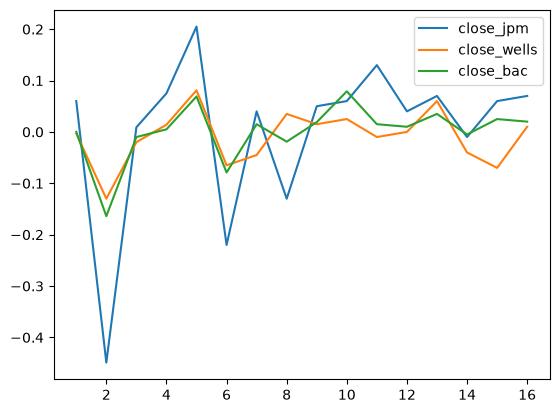

In [66]:
jpm_wells = pd.merge_asof(jp_morgan, wells_fargo, on='date_time', suffixes=('', '_wells'), direction='nearest')
jpm_wells_bac = pd.merge_asof(jpm_wells, bank_of_america, on='date_time', suffixes=('_jpm', '_bac'),direction='nearest')

price_diffs = jpm_wells_bac.diff()

price_diffs.plot(y=['close_jpm', 'close_wells', 'close_bac'])
plt

### Using `merge_asof()` to create dataset

### Fix Panda error - ValueError: Must supply freq for datetime value

(2026-07-19T18:03:36+07:00 - AI Generated with Claude Sonnet 4.6 (Thinking))

This error occurs in pandas when you perform datetime arithmetic or create a date range without specifying a frequency (freq) parameter.

In [67]:

# Convert date string to Panda date time
gdp['date'] = pd.to_datetime(gdp['date'])
recession['date'] = pd.to_datetime(recession['date'])

In [68]:
gdp_recession = pd.merge_asof(gdp, recession, on='date', direction='forward')

is_recession = ['r' if s=='recession' else 'g' for s in gdp_recession['econ_status']]

In [69]:
# Convert date to string to avoid "Must supply freq" error
gdp_recession['date'] = gdp_recession['date'].dt.strftime('%Y-%m-%d')

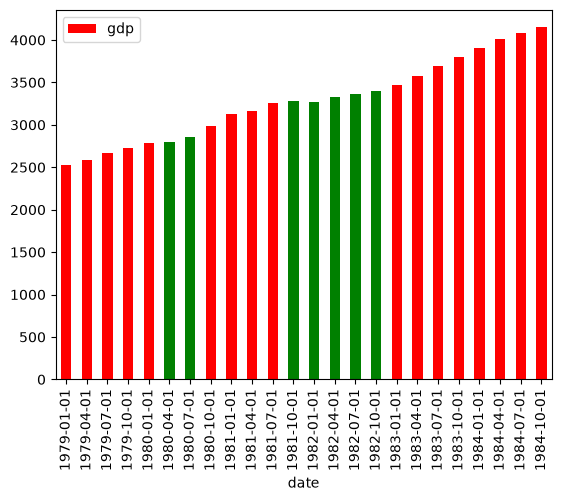

In [70]:

# Plot a bar chart of gdp_recession
gdp_recession.plot(kind='bar', y='gdp', x='date', color=is_recession, rot=90)
plt.show()

## Miscellaneous

### `pandas.DataFrame.shape` - DataFrame Property

```python
df.shape
```

In [71]:
taxi_own_veh.shape

(3519, 10)

### Multiple merges

In [72]:
# Merge licenses and zip_demo, on zip; and merge the wards on ward
licenses_zip_ward = licenses \
                  .merge(zip_demo, on='zip') \
            			.merge(wards, on='ward')

# Print the results by alderman and show median income
licenses_zip_ward.groupby('alderman').agg({'income':'median'})

,income
alderman,
Ameya Pawar,66246.0
Anthony A. Beale,38206.0
Anthony V. Napolitano,82226.0
Ariel E. Reyboras,41307.0
Brendan Reilly,110215.0
Brian Hopkins,87143.0
Carlos Ramirez-Rosa,66246.0
Carrie M. Austin,38206.0
Chris Taliaferro,55566.0


### Index merge

In [73]:
# Merge to the movies table the ratings table on the index
movies_ratings = movies.merge(ratings, on="id")

# Print the first few rows of movies_ratings
movies_ratings.head()

,id,title,popularity,release_date,vote_average,vote_count
0,257,Oliver Twist,20.415572,2005-09-23,6.7,274.0
1,14290,Better Luck Tomorrow,3.877036,2002-01-12,6.5,27.0
2,38365,Grown Ups,38.864027,2010-06-24,6.0,1705.0
3,9672,Infamous,3.680896,2006-11-16,6.4,60.0
4,12819,Alpha and Omega,12.300789,2010-09-17,5.3,124.0


In [74]:
# Merge sequels and financials on index id
sequels_fin = sequels.merge(financials, on='id', how='left')
sequels_fin

,id,title,sequel,budget,revenue
0,19995,Avatar,NaN,237000000.0,2.787965e+09
1,862,Toy Story,863.0,30000000.0,3.735540e+08
2,863,Toy Story 2,10193.0,90000000.0,4.973669e+08
3,597,Titanic,NaN,200000000.0,1.845034e+09
4,24428,The Avengers,NaN,220000000.0,1.519558e+09
...,...,...,...,...,...
4798,133931,Zambezia,NaN,NaN,NaN
4799,309503,Zipper,NaN,NaN,NaN
4800,34592,ZMD: Zombies of Mass Destruction,NaN,NaN,NaN
4801,206213,Zombie Hunter,NaN,NaN,NaN


### Self join

The pandas module limits you to one merge where you merge a table to itself. You cannot repeat this process over and over.

In [75]:
crews_self_merged = crews.merge(crews, on="id", suffixes=['_dir','_crew'])
crews_self_merged

,department_dir,job_dir,name_dir,department_crew,job_crew,name_crew
id,,,,,,
19995,Editing,Editor,Stephen E. Rivkin,Editing,Editor,Stephen E. Rivkin
19995,Editing,Editor,Stephen E. Rivkin,Sound,Sound Designer,Christopher Boyes
19995,Editing,Editor,Stephen E. Rivkin,Production,Casting,Mali Finn
19995,Editing,Editor,Stephen E. Rivkin,Directing,Director,James Cameron
19995,Editing,Editor,Stephen E. Rivkin,Writing,Writer,James Cameron
...,...,...,...,...,...,...
25975,Directing,Director,Jon Gunn,Directing,Director,Brett Winn
25975,Directing,Director,Brett Winn,Production,Executive Producer,Clark Peterson
25975,Directing,Director,Brett Winn,Directing,Director,Brian Herzlinger


### Semi Join


Semi aims to help create an intemediary filtering `Series`.

Filtering observations from table based on whether or not they match an observation in another table.

#### Steps of a semi join

Merge left and right tables on key column using an inner join.

Search if the key column in the left table is in merged tables using `.isin()` method creating a Boolean `Series`

Subset the rows of the left table.

#### Using `isin()`

In [76]:
iron_man_1_movie_id = movies[movies['title'].str.fullmatch('Iron Man')]['id']

# iron_1_actors = actors_movies
iron_1_actors = casts[casts.index.isin(iron_man_1_movie_id)]
iron_1_actors

,cast_id,character,gender,id,name
movie_id,,,,,
1726,9,Yinsen,2,17857,Shaun Toub
1726,10,"Virginia ""Pepper"" Potts",1,12052,Gwyneth Paltrow
1726,11,Obadiah Stane / Iron Monger,2,1229,Jeff Bridges
1726,12,"Lt. Col. James ""Rhodey"" Rhodes / War Machine",2,18288,Terrence Howard
1726,17,Christine Everhart,1,57451,Leslie Bibb
...,...,...,...,...,...
1726,103,Reporter (uncredited),0,1209728,Chris Reid
1726,104,News Cameraman (uncredited),0,1209729,Toi Rose
1726,106,Rooftop Fireman (uncredited),0,1209730,George F. Watson


#### Anti Join - `pandas.DataFrame.merge(indicator=boolean|str)`

Returns the left table, excluding the intersection
Returns only columns from left table and ___not___ the right

#### In more depth
(_2026-07-16T13:10:02+07:00 - AI Generated with Gemini 3.5 Flash (Medium)_)

In `pandas.DataFrame.merge()`, the `indicator` parameter adds a special column to the merged DataFrame that shows the source of each row.

In [77]:
# Merge employees and top_cust
empl_cust = employees.merge(top_cust, on='srid', how='left', indicator=True)

# Select the srid column where _merge is left_only
srid_list = empl_cust.loc[empl_cust['_merge'] == 'left_only', 'srid']

# Get employees not working with top customers
# Use .index since 'srid' is the index of the employees DataFrame
employees[employees.index.isin(srid_list)]

,lname,fname,title,hire_date,email
srid,,,,,
1,Adams,Andrew,General Manager,2002-08-14,andrew@chinookcorp.com
2,Edwards,Nancy,Sales Manager,2002-05-01,nancy@chinookcorp.com
6,Mitchell,Michael,IT Manager,2003-10-17,michael@chinookcorp.com
7,King,Robert,IT Staff,2004-01-02,robert@chinookcorp.com
8,Callahan,Laura,IT Staff,2004-03-04,laura@chinookcorp.com


### Cardinality

Understanding the difference between a one-to-one and one-to-many relationship is a useful skill. In this exercise, consider a set of tables from an e-commerce website. The hypothetical tables are the following:

- A `customer` table with information about each customer
- A `cust_tax_info` table with customers unique tax IDs
- An `orders` table with information about each order
- A `products` table with details about each unique product sold
An inventory table with information on how much total inventory is available to sell for each product

|One-to-one relationship|One-to-many relationship
|--|--|
|`customer` and `cust_tax_info`<hr>`products` and `inventory`|`products` and `orders`<hr>`customer` and `orders`|

#### One-to-many merge with multiple tables


In [78]:
# Merge land_use and census and merge result with licenses including suffixes
land_cen_lic = land_use \
              .merge(census, on='ward') \
              .merge(licenses, on='ward', suffixes=('_cen','_lic'))

# Group by ward, pop_2010, and vacant, then count the # of accounts
pop_vac_lic = land_cen_lic.groupby(['ward','pop_2010','vacant'],
                                   as_index=False).agg({'account':'count'})

# Sort pop_vac_lic and print the results
sorted_pop_vac_lic = pop_vac_lic.sort_values(['vacant', 'account','pop_2010'],
                                             ascending=[False, True, True])

# Print the top few rows of sorted_pop_vac_lic
sorted_pop_vac_lic.head()

,ward,pop_2010,vacant,account
5,7,51581,19,80
18,20,52372,15,123
8,10,51535,14,130
22,24,54909,13,98
14,16,51954,13,156


### `pandas.DataFrame.merge(validate=None|str)` Verifying integrity

Within the context, we're checking what kind of relationship the tables have between, the following string parameters:

- `'one_to_one'`
- `'one_to_many'`
- `'many_to_one'`
- `'many_to_many'`

`'many'` means there are duplicate keys.

> No examples for this `validate` concept